# Modeliranje

Naložimo podatke

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

df = pd.read_csv("./data/processed/koncne_znacilke.csv")

df["tourney_date"] = pd.to_datetime(df["tourney_date"])
df["year"] = df["tourney_date"].dt.year

df = df.sort_values(["tourney_date", "tourney_id", "match_num"]).reset_index(drop=True)

df.head()

,tourney_id,tourney_name,tourney_date,year,match_num,p1_id,p1_name,p2_id,p2_name,target,...,h2h_p2_wins,h2h_winrate_p1,h2h_winrate_diff,surface_h2h_matches,surface_h2h_p1_wins,surface_h2h_p2_wins,surface_h2h_winrate_p1,surface_h2h_winrate_diff,last_h2h_result,p1_higher_elo
0,2000-339,Adelaide,2000-01-03,2000,1,103096,Arnaud Clement,102358,Thomas Enqvist,0,...,0,0.5,0.0,0,0,0,0.5,0.0,0.5,0
1,2000-339,Adelaide,2000-01-03,2000,2,103819,Roger Federer,102533,Jens Knippschild,1,...,0,0.5,0.0,0,0,0,0.5,0.0,0.5,0
2,2000-339,Adelaide,2000-01-03,2000,3,101885,Wayne Arthurs,102998,Jan Michael Gambill,0,...,0,0.5,0.0,0,0,0,0.5,0.0,0.5,0
3,2000-339,Adelaide,2000-01-03,2000,4,102776,Andrew Ilie,103206,Sebastien Grosjean,0,...,0,0.5,0.0,0,0,0,0.5,0.0,0.5,0
4,2000-339,Adelaide,2000-01-03,2000,5,102796,Magnus Norman,102401,Scott Draper,1,...,0,0.5,0.0,0,0,0,0.5,0.0,0.5,0


Ločimo učne, validacijske in testne podatke. Uporabimo časovni split (po letih) namesto naključnega, ker bi naključni split lahko vodil v data leakage - model bi se učil na podlagi prihodnjih tekem za napovedovanje preteklih.

In [2]:
train_df = df[df["year"].between(2000, 2021)].copy()
val_df = df[df["year"] == 2022].copy()
test_df = df[df["year"].between(2023, 2024)].copy()
future_df = df[df["year"].between(2025, 2026)].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Future:", future_df.shape)

Train: (57281, 57)
Validation: (2620, 57)
Test: (5389, 57)
Future: (3489, 57)


Določimo značilke

In [3]:
basic_numeric_features = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "round_num",
    "draw_size",
]

basic_categorical_features = [
    "surface",
    "tourney_level",
    "best_of",
    "round",
    "hand_matchup",
]

historical_numeric_features = [
    "elo_diff",
    "surface_elo_diff",
    "last10_winrate_diff",
    "surface_winrate_diff",
    "matches_played_diff",
    "surface_matches_played_diff",
    
    "h2h_matches",
    "h2h_winrate_diff",
    "surface_h2h_matches",
    "surface_h2h_winrate_diff",
    "last_h2h_result",
]

Preverimo da obstajajo vsi stolpci

In [4]:
all_needed_cols = (
    basic_numeric_features
    + basic_categorical_features
    + historical_numeric_features
    + ["target"]
)

missing_cols = [col for col in all_needed_cols if col not in df.columns]
missing_cols

[]

Pripravimo atribute in razred

In [5]:
basic_features = basic_numeric_features + basic_categorical_features

X_train_basic = train_df[basic_features]
y_train = train_df["target"]

X_val_basic = val_df[basic_features]
y_val = val_df["target"]

X_test_basic = test_df[basic_features]
y_test = test_df["target"]

In [6]:
final_features = basic_numeric_features + historical_numeric_features + basic_categorical_features

X_train_final = train_df[final_features]
X_val_final = val_df[final_features]
X_test_final = test_df[final_features]


In [7]:
if len(future_df) > 0:
    X_future_final = future_df[final_features]
    y_future = future_df["target"]

### Predprocesiranje

In [8]:
def make_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor

In [9]:
basic_preprocessor = make_preprocessor(
    numeric_features=basic_numeric_features,
    categorical_features=basic_categorical_features
)

In [10]:
final_preprocessor = make_preprocessor(
    numeric_features=basic_numeric_features + historical_numeric_features,
    categorical_features=basic_categorical_features
)

### Funkcija za evalvacijo in izpis

In [11]:
def evaluate_model(model, X, y, model_name="Model"):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_proba),
        "log_loss": log_loss(y, y_proba)
    }

    return results

In [12]:
def print_model_report(model, X, y, model_name="Model"):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    print(model_name)
    print("-" * len(model_name))
    print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
    print(f"AUC:      {roc_auc_score(y, y_proba):.4f}")
    print(f"Log loss: {log_loss(y, y_proba):.4f}")
    print()
    print(classification_report(y, y_pred))

## Modeli

In [13]:
results = []

### Baza za primerjanje

In [14]:
def ranking_baseline_predict(X):
    return (X["rank_diff"] < 0).astype(int)

In [15]:
baseline_pred = ranking_baseline_predict(X_test_basic)

baseline_results = {
    "model": "Baseline: better ranked player",
    "accuracy": accuracy_score(y_test, baseline_pred),
    "auc": roc_auc_score(y_test, baseline_pred),
    "log_loss": np.nan
}

results.append(baseline_results)

baseline_results

{'model': 'Baseline: better ranked player',
 'accuracy': 0.6349972165522361,
 'auc': 0.6349819853028282,
 'log_loss': nan}

### Logistična regresija

#### Osnovne značilke

In [16]:
logreg_basic = Pipeline(steps=[
    ("preprocessor", basic_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_basic.fit(X_train_basic, y_train)

print_model_report(
    logreg_basic,
    X_test_basic,
    y_test,
    "Logistic Regression - basic features"
)

results.append(
    evaluate_model(
        logreg_basic,
        X_test_basic,
        y_test,
        "Logistic Regression - basic"
    )
)

Logistic Regression - basic features
------------------------------------
Accuracy: 0.6343
AUC:      0.6962
Log loss: 0.6359

              precision    recall  f1-score   support

           0       0.64      0.64      0.64      2721
           1       0.63      0.63      0.63      2668

    accuracy                           0.63      5389
   macro avg       0.63      0.63      0.63      5389
weighted avg       0.63      0.63      0.63      5389



#### Zgodovinske značilke

In [17]:
logreg_final = Pipeline(steps=[
    ("preprocessor", final_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_final.fit(X_train_final, y_train)

print_model_report(
    logreg_final,
    X_test_final,
    y_test,
    "Logistic Regression - basic + historical"
)

results.append(
    evaluate_model(
        logreg_final,
        X_test_final,
        y_test,
        "Logistic Regression - historical"
    )
)

Logistic Regression - basic + historical
----------------------------------------
Accuracy: 0.6498
AUC:      0.7173
Log loss: 0.6162

              precision    recall  f1-score   support

           0       0.65      0.65      0.65      2721
           1       0.65      0.65      0.65      2668

    accuracy                           0.65      5389
   macro avg       0.65      0.65      0.65      5389
weighted avg       0.65      0.65      0.65      5389



### Random forest

In [18]:
rf_final = Pipeline(steps=[
    ("preprocessor", final_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_final.fit(X_train_final, y_train)

print_model_report(
    rf_final,
    X_test_final,
    y_test,
    "Random Forest - historical"
)

results.append(
    evaluate_model(
        rf_final,
        X_test_final,
        y_test,
        "Random Forest - historical"
    )
)

Random Forest - historical
--------------------------
Accuracy: 0.6498
AUC:      0.7178
Log loss: 0.6141

              precision    recall  f1-score   support

           0       0.65      0.65      0.65      2721
           1       0.65      0.65      0.65      2668

    accuracy                           0.65      5389
   macro avg       0.65      0.65      0.65      5389
weighted avg       0.65      0.65      0.65      5389



### XGBoost

In [19]:
xgb_final = Pipeline(steps=[
    ("preprocessor", final_preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ))
])

xgb_final.fit(X_train_final, y_train)

print_model_report(
    xgb_final,
    X_test_final,
    y_test,
    "XGBoost - historical"
)

results.append(
    evaluate_model(
        xgb_final,
        X_test_final,
        y_test,
        "XGBoost - historical"
    )
)

XGBoost - historical
--------------------
Accuracy: 0.6495
AUC:      0.7209
Log loss: 0.6122

              precision    recall  f1-score   support

           0       0.65      0.66      0.65      2721
           1       0.65      0.64      0.64      2668

    accuracy                           0.65      5389
   macro avg       0.65      0.65      0.65      5389
weighted avg       0.65      0.65      0.65      5389



## Primerjava rezultatov

In [20]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("auc", ascending=False)

results_df

,model,accuracy,auc,log_loss
4,XGBoost - historical,0.649471,0.720860,0.612177
3,Random Forest - historical,0.649842,0.717756,0.614115
2,Logistic Regression - historical,0.649842,0.717288,0.616200
1,Logistic Regression - basic,0.634255,0.696231,0.635949
0,Baseline: better ranked player,0.634997,0.634982,NaN


Shranimo rezultate

In [21]:
results_df.to_csv("./data/processed/rezultati_modelov.csv", index=False)

### Prikaz rezultatov

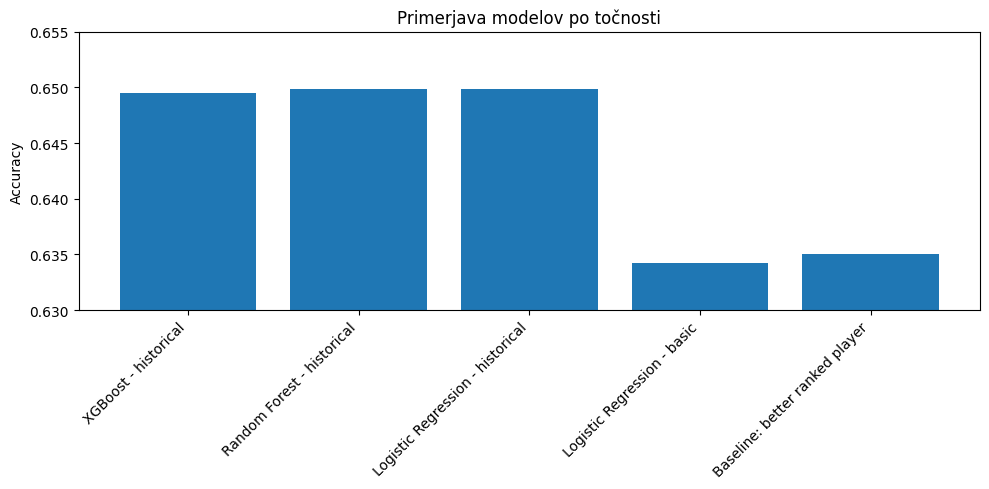

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Primerjava modelov po točnosti")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.63, 0.655)
plt.tight_layout()
plt.show()

### Confusion matrix

Za najboljši model (XGBoost) prikažemo absolutno in normalizirano confusion matrix na testni množici.

In [23]:
best_model = xgb_final
best_X_test = X_test_final
best_model_name = "XGBoost - historical"

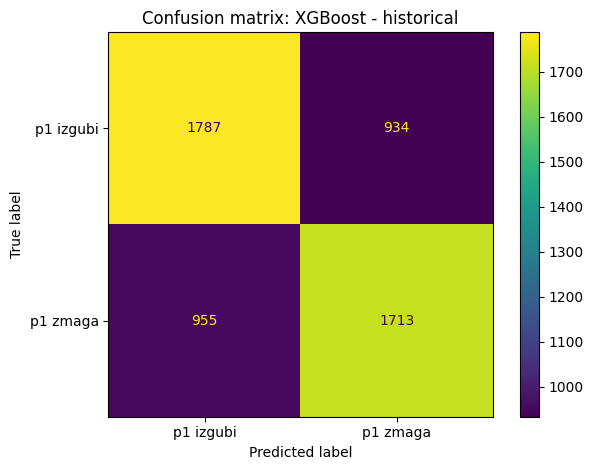

In [24]:
y_pred = best_model.predict(best_X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["p1 izgubi", "p1 zmaga"]
)

disp.plot()
plt.title(f"Confusion matrix: {best_model_name}")
plt.tight_layout()
plt.show()

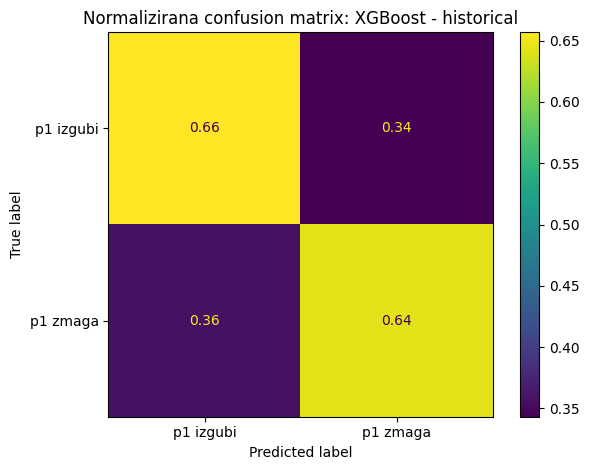

In [25]:
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["p1 izgubi", "p1 zmaga"]
)

disp.plot(values_format=".2f")
plt.title(f"Normalizirana confusion matrix: {best_model_name}")
plt.tight_layout()
plt.show()

### ROC krivulje

<Figure size 800x600 with 0 Axes>

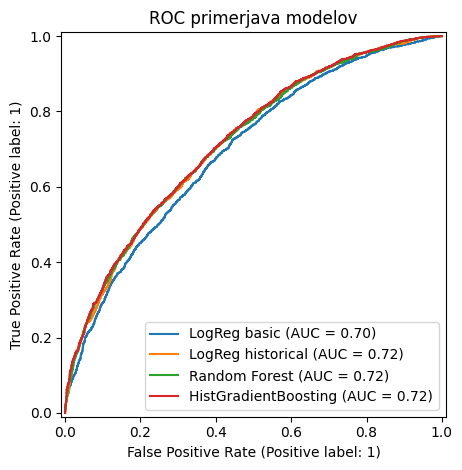

In [26]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    logreg_basic,
    X_test_basic,
    y_test,
    name="LogReg basic"
)

RocCurveDisplay.from_estimator(
    logreg_final,
    X_test_final,
    y_test,
    name="LogReg historical",
    ax=plt.gca()
)

RocCurveDisplay.from_estimator(
    rf_final,
    X_test_final,
    y_test,
    name="Random Forest",
    ax=plt.gca()
)

RocCurveDisplay.from_estimator(
    xgb_final,
    X_test_final,
    y_test,
    name="HistGradientBoosting",
    ax=plt.gca()
)

plt.title("ROC primerjava modelov")
plt.tight_layout()
plt.show()

### Pomembnost značilk

Za Random Forest pogledamo feature importance, za logistično regresijo pa absolutne velikosti koeficientov - tako vidimo, kateri atributi najbolj vplivajo na napoved.

In [27]:
def get_feature_names_from_pipeline(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]

    numeric_features = preprocessor.transformers_[0][2]

    categorical_transformer = preprocessor.transformers_[1][1]
    categorical_features = preprocessor.transformers_[1][2]

    onehot = categorical_transformer.named_steps["onehot"]
    categorical_feature_names = onehot.get_feature_names_out(categorical_features)

    return np.concatenate([numeric_features, categorical_feature_names])

In [28]:
feature_names = get_feature_names_from_pipeline(rf_final)
importances = rf_final.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
6,elo_diff,0.176367
7,surface_elo_diff,0.165132
1,rank_points_diff,0.143930
0,rank_diff,0.125955
9,surface_winrate_diff,0.092308
8,last10_winrate_diff,0.055283
11,surface_matches_played_diff,0.054157
10,matches_played_diff,0.049700
2,age_diff,0.036426
3,height_diff,0.017303


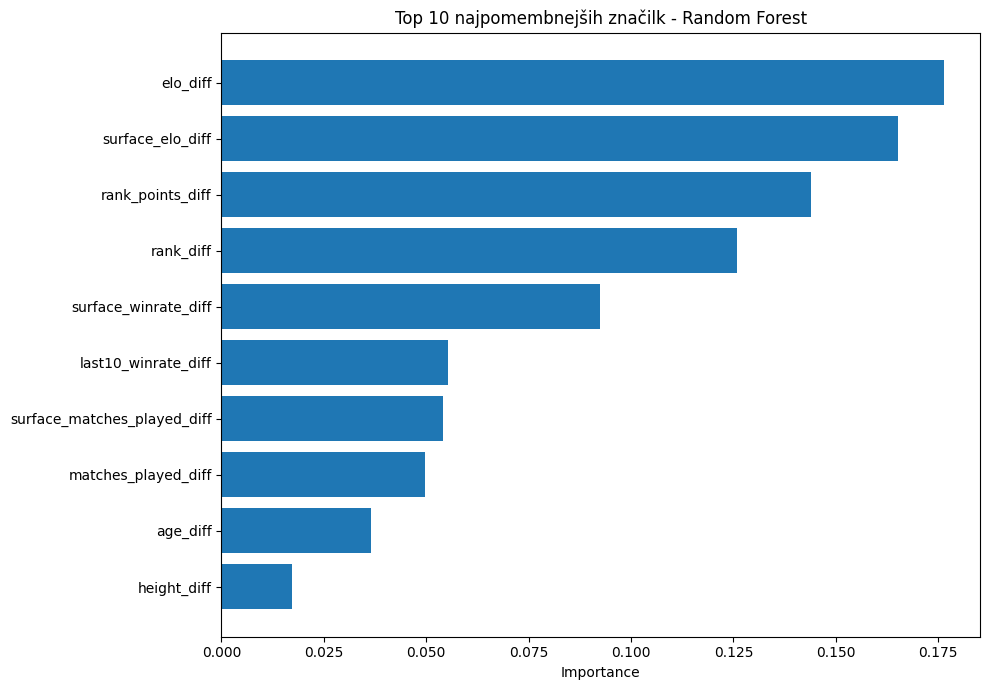

In [29]:
top_importance = importance_df.head(10).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Top 10 najpomembnejših značilk - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [30]:
feature_names = get_feature_names_from_pipeline(logreg_final)
coefs = logreg_final.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
})

coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df.sort_values("abs_coef", ascending=False).head(20)

,feature,coef,abs_coef
6,elo_diff,0.411966,0.411966
7,surface_elo_diff,0.326078,0.326078
0,rank_diff,-0.292299,0.292299
2,age_diff,-0.179514,0.179514
11,surface_matches_played_diff,0.142604,0.142604
9,surface_winrate_diff,0.119196,0.119196
1,rank_points_diff,0.093330,0.093330
10,matches_played_diff,-0.082681,0.082681
5,draw_size,0.074107,0.074107
17,surface_Carpet,-0.072541,0.072541


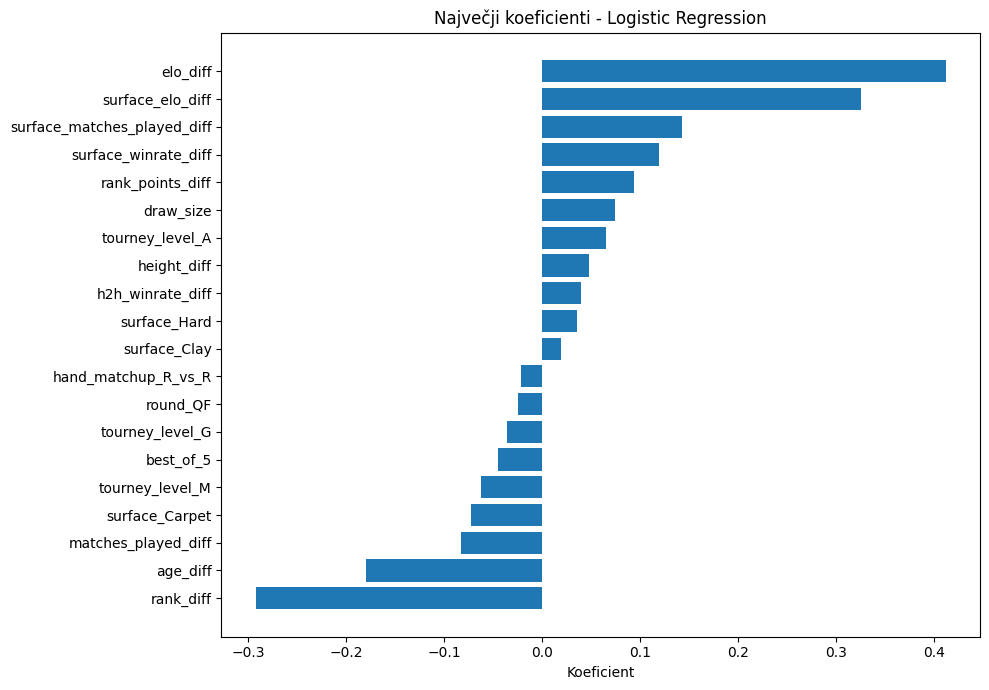

In [31]:
top_coef = coef_df.sort_values("abs_coef", ascending=False).head(20)
top_coef = top_coef.sort_values("coef")

plt.figure(figsize=(10, 7))
plt.barh(top_coef["feature"], top_coef["coef"])
plt.title("Največji koeficienti - Logistic Regression")
plt.xlabel("Koeficient")
plt.tight_layout()
plt.show()

### Primeri napovedi

Najprej pogledamo nekaj vrstic z napovedmi, nato sortiramo pravilne napovedi po največji gotovosti modela in narobne napovedi po največji "samozavestni" napaki.

In [32]:
test_predictions = test_df.copy()

test_predictions["pred_proba_p1_win"] = best_model.predict_proba(best_X_test)[:, 1]
test_predictions["pred"] = (test_predictions["pred_proba_p1_win"] >= 0.5).astype(int)
test_predictions["correct"] = test_predictions["pred"] == test_predictions["target"]

test_predictions[[
    "tourney_date",
    "tourney_name",
    "surface",
    "p1_name",
    "p2_name",
    "target",
    "pred",
    "pred_proba_p1_win",
    "correct"
]].head(10)

,tourney_date,tourney_name,surface,p1_name,p2_name,target,pred,pred_proba_p1_win,correct
59901,2023-01-02,Pune,Hard,Sasi Kumar Mukund,Flavio Cobolli,0,0,0.361398,True
59902,2023-01-02,Pune,Hard,Maximilian Marterer,Elias Ymer,1,0,0.452665,False
59903,2023-01-02,Pune,Hard,Laslo Djere,Alex Molcan,1,0,0.487715,False
59904,2023-01-02,Pune,Hard,Benjamin Bonzi,Chun Hsin Tseng,1,1,0.644390,True
59905,2023-01-02,Pune,Hard,Sumit Nagal,Filip Krajinovic,0,0,0.133906,True
59906,2023-01-02,Pune,Hard,Aslan Karatsev,Pablo Andujar,1,1,0.560202,True
59907,2023-01-02,Pune,Hard,Radu Albot,Tim Van Rijthoven,0,1,0.507509,False
59908,2023-01-02,Pune,Hard,Ramkumar Ramanathan,Pedro Martinez,0,0,0.193471,True
59909,2023-01-02,Pune,Hard,Jaume Munar,Tallon Griekspoor,0,1,0.538355,False
59910,2023-01-02,Pune,Hard,Nikoloz Basilashvili,Marco Cecchinato,0,1,0.670034,False


In [33]:
test_predictions[test_predictions["correct"]].sort_values(
    "pred_proba_p1_win",
    ascending=False
)[[
    "tourney_date",
    "tourney_name",
    "surface",
    "p1_name",
    "p2_name",
    "target",
    "pred",
    "pred_proba_p1_win"
]].head(10)

,tourney_date,tourney_name,surface,p1_name,p2_name,target,pred,pred_proba_p1_win
64623,2024-08-26,Us Open,Hard,Carlos Alcaraz,Li Tu,1,1,0.987565
64696,2024-08-26,Us Open,Hard,Jannik Sinner,Christopher Oconnell,1,1,0.981440
64652,2024-08-26,Us Open,Hard,Alexander Zverev,Maximilian Marterer,1,1,0.978936
63880,2024-05-27,Roland Garros,Clay,Carlos Alcaraz,J J Wolf,1,1,0.978900
63881,2024-05-27,Roland Garros,Clay,Jannik Sinner,Christopher Eubanks,1,1,0.976701
64607,2024-08-26,Us Open,Hard,Jannik Sinner,Mackenzie Mcdonald,1,1,0.976589
60122,2023-01-16,Australian Open,Hard,Stefanos Tsitsipas,Rinky Hijikata,1,1,0.976125
64121,2024-07-01,Wimbledon,Grass,Carlos Alcaraz,Mark Lajal,1,1,0.973870
61542,2023-07-03,Wimbledon,Grass,Novak Djokovic,Stan Wawrinka,1,1,0.972508
64105,2024-07-01,Wimbledon,Grass,Jannik Sinner,Yannick Hanfmann,1,1,0.970743


In [34]:
test_predictions[~test_predictions["correct"]].assign(
    confidence=lambda x: np.maximum(
        x["pred_proba_p1_win"],
        1 - x["pred_proba_p1_win"]
    )
).sort_values("confidence", ascending=False)[[
    "tourney_date",
    "tourney_name",
    "surface",
    "p1_name",
    "p2_name",
    "target",
    "pred",
    "pred_proba_p1_win",
    "confidence"
]].head(10)

,tourney_date,tourney_name,surface,p1_name,p2_name,target,pred,pred_proba_p1_win,confidence
64675,2024-08-26,Us Open,Hard,Carlos Alcaraz,Botic Van De Zandschulp,0,1,0.969721,0.969721
62796,2024-01-15,Australian Open,Hard,Nuno Borges,Grigor Dimitrov,1,0,0.037827,0.962173
60140,2023-01-16,Australian Open,Hard,Michael Mmoh,Alexander Zverev,1,0,0.038107,0.961893
62307,2023-10-16,Tokyo,Hard,Taylor Fritz,Shintaro Mochizuki,0,1,0.961764,0.961764
61201,2023-05-29,Roland Garros,Clay,Daniil Medvedev,Thiago Seyboth Wild,0,1,0.951644,0.951644
61225,2023-05-29,Roland Garros,Clay,Jannik Sinner,Daniel Altmaier,0,1,0.941623,0.941623
63245,2024-03-04,Indian Wells Masters,Hard,Luca Nardi,Novak Djokovic,1,0,0.062831,0.937169
62770,2024-01-15,Australian Open,Hard,Holger Rune,Arthur Cazaux,0,1,0.936370,0.936370
60528,2023-03-06,Indian Wells Masters,Hard,Stefanos Tsitsipas,Jordan Thompson,0,1,0.935313,0.935313
62453,2023-10-30,Paris Masters,Hard,Carlos Alcaraz,Roman Safiullin,0,1,0.929551,0.929551
